# Import Data 

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

df = pd.read_csv("1429_1.csv")


/var/folders/db/87d025j5081fm4bs5t49d62r0000gn/T/ipykernel_5438/4015373944.py:7: DtypeWarning: Columns (1,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("1429_1.csv")


## EDA

#### Dataset Overview

In [118]:
display(df.head())

,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,NaN,NaN,Adapter
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,NaN,NaN,truman
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,I've had my Fire HD 8 two weeks now and I love...,Good!!!,NaN,NaN,Shacks
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,NaN,NaN,explore42


In [119]:
print(df.shape)

(34660, 21)


In [120]:
print(df.columns.tolist())


['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer', 'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen', 'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id', 'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs', 'reviews.text', 'reviews.title', 'reviews.userCity', 'reviews.userProvince', 'reviews.username']


In [121]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34660 entries, 0 to 34659
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    34660 non-null  object 
 1   name                  27900 non-null  object 
 2   asins                 34658 non-null  object 
 3   brand                 34660 non-null  object 
 4   categories            34660 non-null  object 
 5   keys                  34660 non-null  object 
 6   manufacturer          34660 non-null  object 
 7   reviews.date          34621 non-null  object 
 8   reviews.dateAdded     24039 non-null  object 
 9   reviews.dateSeen      34660 non-null  object 
 10  reviews.didPurchase   1 non-null      object 
 11  reviews.doRecommend   34066 non-null  object 
 12  reviews.id            1 non-null      float64
 13  reviews.numHelpful    34131 non-null  float64
 14  reviews.rating        34627 non-null  float64
 15  reviews.sourceURLs 

In [122]:

df.describe(include="all")

,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
count,34660,27900,34658,34660,34660,34660,34660,34621,24039,34660,...,34066,1.0,34131.000000,34627.000000,34660,34659,34654,0.0,0.0,34653
unique,42,48,41,6,41,42,2,1078,1941,3911,...,2,NaN,NaN,NaN,11929,34659,19766,NaN,NaN,26788
top,AVphgVaX1cnluZ0-DR74,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",B018Y229OU,Amazon,"Fire Tablets,Tablets,Computers & Tablets,All T...",firetablet7displaywifi8gbincludesspecialoffers...,Amazon,2017-01-16T00:00:00.000Z,2017-09-05T22:09:30Z,"2017-09-28T00:00:00Z,2017-09-08T00:00:00Z,2017...",...,True,NaN,NaN,NaN,https://www.amazon.com/product-reviews/B01J2G4...,to spite the fact that i have nothing but good...,Great product,NaN,NaN,Mike
freq,10966,10966,10966,28701,10966,10966,34639,710,3127,5072,...,32682,NaN,NaN,NaN,387,1,645,NaN,NaN,138
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,111372787.0,0.630248,4.584573,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,13.215775,0.735653,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,111372787.0,0.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,111372787.0,0.000000,4.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,111372787.0,0.000000,5.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,111372787.0,0.000000,5.000000,NaN,NaN,NaN,NaN,NaN,NaN


#### Missing Values

In [123]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing": missing, "%": missing_pct})

,missing,%
reviews.userCity,34660,100.00
reviews.userProvince,34660,100.00
reviews.id,34659,100.00
reviews.didPurchase,34659,100.00
reviews.dateAdded,10621,30.64
name,6760,19.50
reviews.doRecommend,594,1.71
reviews.numHelpful,529,1.53
reviews.date,39,0.11
reviews.rating,33,0.10


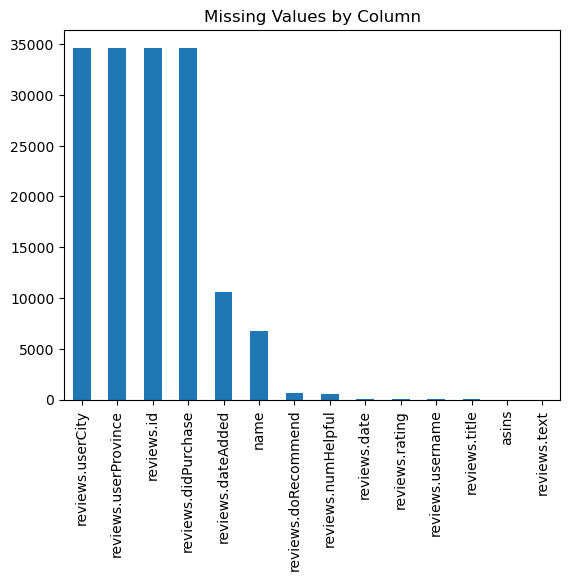

In [124]:
import matplotlib.pyplot as plt

missing[missing > 0].plot(kind="bar")
plt.title("Missing Values by Column")
plt.show()

In [125]:
# Nearly empty columns (>99% missing) -> candidates for removal
empty_cols = missing_pct[missing_pct > 99].index.tolist()
print("Columns >99% missing:", empty_cols)

# Constant columns (single value) -> carry no information
constant_cols = [c for c in df.columns if df[c].nunique(dropna=True) <= 1]
print("Constant columns:", constant_cols)

Columns >99% missing: ['reviews.userCity', 'reviews.userProvince', 'reviews.id', 'reviews.didPurchase']
Constant columns: ['reviews.didPurchase', 'reviews.id', 'reviews.userCity', 'reviews.userProvince']


####  Duplicate Analysis

In [126]:
df.duplicated().sum()

0

In [127]:
df["reviews.text"].duplicated().sum()

0

#### Target Variable Exploration (Ratings)

In [128]:
df["reviews.rating"].value_counts().sort_index()

reviews.rating
1.0      410
2.0      402
3.0     1499
4.0     8541
5.0    23775
Name: count, dtype: int64

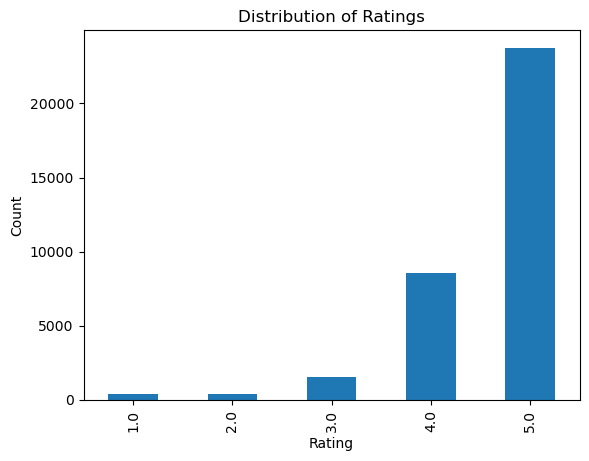

In [129]:
df["reviews.rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

#### Brand Distribution

In [130]:
df["brand"].value_counts().head(15)


brand
Amazon                          28701
Amazon Fire Tv                   5056
Amazon Echo                       636
Amazon Fire                       256
Amazon Digital Services Inc.       10
Amazon Coco T                       1
Name: count, dtype: int64

#### Categories

In [131]:
df["categories"].value_counts().head(15)

categories
Fire Tablets,Tablets,Computers & Tablets,All Tablets,Electronics, Tech Toys, Movies, Music,Electronics,iPad & Tablets,Android Tablets,Frys                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               10966
Stereos,Remote Controls,Amazon Echo,Audio Docks & Mini Speakers,Amazon Echo Accessories,Kitchen & Dining Features,Speaker Systems,Electronics,TVs Entertainment,Clearance,Smart Hubs & Wireless Routers,Featured Brands,Wireless Speakers,Smart Home & Connect

#### Review Length

In [132]:
df["review_length"] = df["reviews.text"].str.len()

In [133]:
df["review_length"].describe()

count    34659.000000
mean       159.047434
std        185.837884
min          3.000000
25%         70.000000
50%        106.000000
75%        183.000000
max      10670.000000
Name: review_length, dtype: float64

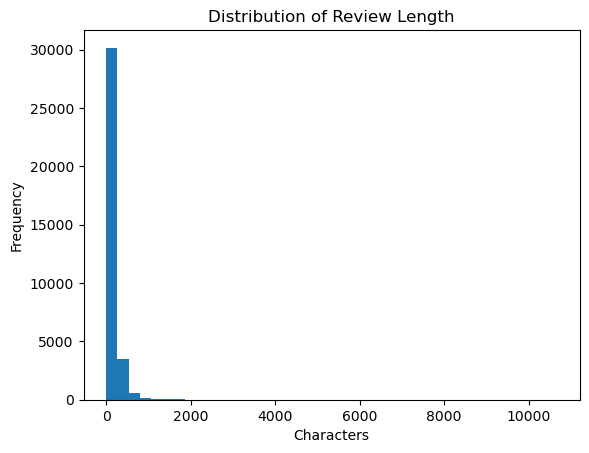

In [134]:
plt.hist(df["review_length"], bins=40)
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.title("Distribution of Review Length")
plt.show()

#### Word Count

In [135]:
df["word_count"] = df["reviews.text"].str.split().str.len()

In [136]:
df["word_count"].describe()

count    34659.000000
mean        30.404166
std         34.641555
min          1.000000
25%         13.000000
50%         21.000000
75%         35.000000
max       1858.000000
Name: word_count, dtype: float64

##### Most Frequent Words

In [137]:
df = df.dropna(subset=["reviews.text"])

In [138]:
from collections import Counter

words = " ".join(df["reviews.text"]).lower().split()

Counter(words).most_common(30)

[('the', 43961),
 ('and', 33707),
 ('to', 33557),
 ('i', 31427),
 ('for', 26019),
 ('a', 24943),
 ('it', 24544),
 ('is', 20687),
 ('my', 17317),
 ('this', 17062),
 ('of', 11061),
 ('great', 10106),
 ('with', 9302),
 ('on', 7989),
 ('have', 7951),
 ('you', 7734),
 ('that', 7230),
 ('in', 6891),
 ('but', 6674),
 ('love', 6489),
 ('tablet', 6480),
 ('was', 6477),
 ('as', 6397),
 ('easy', 5944),
 ('so', 5941),
 ('very', 5707),
 ('use', 5447),
 ('not', 5414),
 ('can', 5404),
 ('amazon', 5311)]

#### Sentiment Distribution

In [139]:
def map_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

df["sentiment"] = df["reviews.rating"].apply(map_sentiment)

In [140]:
print(df["reviews.rating"].value_counts(dropna=False).sort_index())
print(df["sentiment"].value_counts())

reviews.rating
1.0      410
2.0      402
3.0     1499
4.0     8541
5.0    23774
NaN       33
Name: count, dtype: int64
sentiment
Positive    32348
Neutral      1499
Negative      812
Name: count, dtype: int64


<Axes: xlabel='sentiment'>

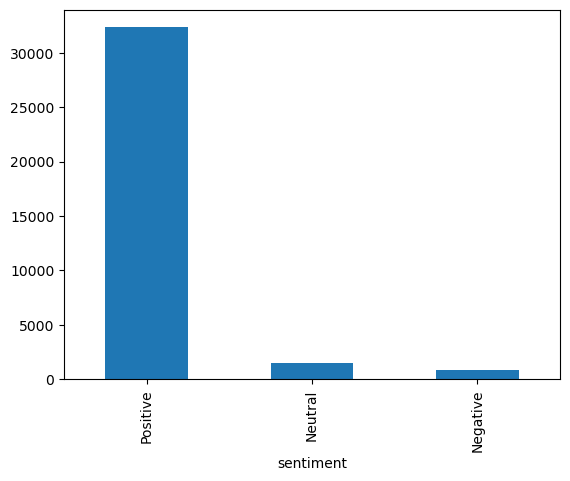

In [141]:
df["sentiment"].value_counts().plot(kind="bar")

#### Review Length vs Rating

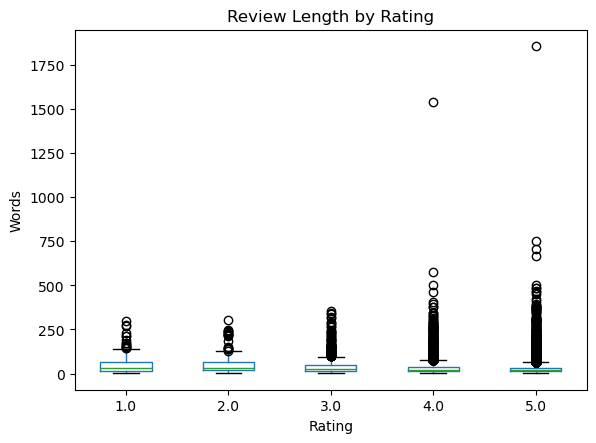

In [142]:
import matplotlib.pyplot as plt

df.boxplot(column="word_count", by="reviews.rating", grid=False)
plt.title("Review Length by Rating")
plt.suptitle("")
plt.xlabel("Rating")
plt.ylabel("Words")
plt.show()

#### Top Products

In [143]:
df["name"].value_counts().head(10)

name
Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta                                                                           10966
Echo (White),,,\r\nEcho (White),,,                                                                                                                3309
Amazon Kindle Paperwhite - eBook reader - 4 GB - 6 monochrome Paperwhite - touchscreen - Wi-Fi - black,,,                                         3176
All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta                                                           2814
Amazon Fire Tv,,,\r\nAmazon Fire Tv,,,                                                                                                            2527
Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Green Kid-Proof Case                                                                           1685
Brand New Amazon Kindle Fire 16gb 7 Ips Display Tablet Wifi 16 Gb Blue,,,                

#### Top Brands

In [144]:
df.groupby("brand")["reviews.rating"].mean().sort_values(ascending=False)

brand
Amazon Fire Tv                  4.707278
Amazon                          4.564706
Amazon Fire                     4.558594
Amazon Echo                     4.531447
Amazon Digital Services Inc.    3.500000
Amazon Coco T                        NaN
Name: reviews.rating, dtype: float64

#### Correlation

In [145]:
df[["reviews.rating","reviews.numHelpful","word_count"]].corr()

,reviews.rating,reviews.numHelpful,word_count
reviews.rating,1.000000,-0.042395,-0.109763
reviews.numHelpful,-0.042395,1.000000,0.218580
word_count,-0.109763,0.218580,1.000000


## Data cleaning before spliting 


#### Dorping Colums 

In [146]:
columns_to_keep = [
    "name",
    "brand",
    "categories",
    "reviews.rating",
    "reviews.text",
    "reviews.title",
    "reviews.numHelpful",
    "reviews.doRecommend",
    "sentiment"
]

df = df[columns_to_keep].copy()

In [147]:
df.isnull().sum()

name                   6760
brand                     0
categories                0
reviews.rating           33
reviews.text              0
reviews.title             6
reviews.numHelpful      528
reviews.doRecommend     593
sentiment                 0
dtype: int64

#### handeling missing values 

In [148]:
# Check missing values
missing = df.isnull().sum().sort_values(ascending=False)

print(missing)

name                   6760
reviews.doRecommend     593
reviews.numHelpful      528
reviews.rating           33
reviews.title             6
reviews.text              0
categories                0
brand                     0
sentiment                 0
dtype: int64


In [149]:
df[["name", "brand", "categories"]].isnull().sum()

name          6760
brand            0
categories       0
dtype: int64

In [150]:
df[df["name"].isna()]

,name,brand,categories,reviews.rating,reviews.text,reviews.title,reviews.numHelpful,reviews.doRecommend,sentiment
27900,NaN,Amazon,"Stereos,Remote Controls,Amazon Echo,Audio Dock...",4.0,Doesn't always do what I asked for. It is prob...,Nice to not have to use a switch somewhere.,0.0,True,Positive
27901,NaN,Amazon,"Stereos,Remote Controls,Amazon Echo,Audio Dock...",5.0,I absolutely love this devise. I do wish ti wa...,It is all that it is advertised to be!,0.0,True,Positive
27902,NaN,Amazon,"Stereos,Remote Controls,Amazon Echo,Audio Dock...",5.0,Absolutely love this thing! It controls my lig...,Couldn't be happier,0.0,True,Positive
27903,NaN,Amazon,"Stereos,Remote Controls,Amazon Echo,Audio Dock...",5.0,I bought this echo when it was first released ...,Make sure your home is equipped.,0.0,True,Positive
27904,NaN,Amazon,"Stereos,Remote Controls,Amazon Echo,Audio Dock...",5.0,The Amazon Echo is super easy to set up. Once ...,Easy to use and very helpful,0.0,True,Positive
...,...,...,...,...,...,...,...,...,...
34655,NaN,Amazon,"Computers/Tablets & Networking,Tablet & eBook ...",3.0,This is not appreciably faster than any other ...,Not appreciably faster than any other 1.8A cha...,NaN,NaN,Neutral
34656,NaN,Amazon,"Computers/Tablets & Networking,Tablet & eBook ...",1.0,Amazon should include this charger with the Ki...,Should be included,NaN,NaN,Negative
34657,NaN,Amazon,"Computers/Tablets & Networking,Tablet & eBook ...",1.0,Love my Kindle Fire but I am really disappoint...,Disappointing Charger,NaN,NaN,Negative
34658,NaN,Amazon,"Computers/Tablets & Networking,Tablet & eBook ...",1.0,I was surprised to find it did not come with a...,Not worth the money,NaN,NaN,Negative


In [152]:
df[df["name"].isna()][
    ["brand", "categories", "reviews.text", "reviews.rating"]
].head(10)

,brand,categories,reviews.text,reviews.rating
27900,Amazon,"Stereos,Remote Controls,Amazon Echo,Audio Dock...",Doesn't always do what I asked for. It is prob...,4.0
27901,Amazon,"Stereos,Remote Controls,Amazon Echo,Audio Dock...",I absolutely love this devise. I do wish ti wa...,5.0
27902,Amazon,"Stereos,Remote Controls,Amazon Echo,Audio Dock...",Absolutely love this thing! It controls my lig...,5.0
27903,Amazon,"Stereos,Remote Controls,Amazon Echo,Audio Dock...",I bought this echo when it was first released ...,5.0
27904,Amazon,"Stereos,Remote Controls,Amazon Echo,Audio Dock...",The Amazon Echo is super easy to set up. Once ...,5.0
27905,Amazon,"Stereos,Remote Controls,Amazon Echo,Audio Dock...","My family and i love it,its now a member of ou...",5.0
27906,Amazon,"Stereos,Remote Controls,Amazon Echo,Audio Dock...","I was very skeptical at first with this, but A...",5.0
27907,Amazon,"Stereos,Remote Controls,Amazon Echo,Audio Dock...","From news, to music, to the weather and much m...",5.0
27908,Amazon,"Stereos,Remote Controls,Amazon Echo,Audio Dock...",I love just being able to wake up in the morni...,5.0
27909,Amazon,"Stereos,Remote Controls,Amazon Echo,Audio Dock...","Originally figured this would be almost a toy,...",5.0


#### Removing rows without review text and rating

In [ ]:
df = df.dropna(subset=["reviews.text"])

In [ ]:
df = df.dropna(subset=["reviews.rating"])